This notebook builds a simple medical report generation system using synthetic radiology data.

The workflow is:

Structured radiology data
↓
Generate clinical history
↓
Generate technique section
↓
Generate findings section
↓
Generate impression section
↓
Combine into full report
↓
Check report quality
↓
Save reports and summary files

This is an educational project only.

It does not use real patient data.

It does not replace radiologists or clinicians.

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

Step 1: Import Libraries

We import libraries for:

data tables
random synthetic data generation
charts
report saving
simple analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime, timedelta
import random
import os
import sys

from sklearn.preprocessing import LabelEncoder

np.random.seed(42)
random.seed(42)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

print("Libraries imported successfully.")
print("Python version:", sys.version)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Libraries imported successfully.
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Pandas version: 2.2.2
NumPy version: 2.0.2


Step 2: Create Synthetic Radiology Dataset

We will create fake chest imaging records.

Each record contains:

patient ID
age
gender
exam date
clinical indication
imaging modality
lung finding
heart size
pleural finding
bone finding
additional finding
impression category

This is synthetic data for learning and portfolio use.

In [3]:
genders = ["Male", "Female"]

indications = [
    "Shortness of breath",
    "Chest pain",
    "Cough and fever",
    "Follow-up study",
    "Post-operative evaluation",
    "Trauma",
    "Routine screening"
]

modalities = [
    "Chest X-ray PA and Lateral",
    "Chest X-ray Portable",
    "CT Chest without contrast"
]

lung_findings = [
    "Clear",
    "Infiltrate present",
    "Consolidation",
    "Nodule",
    "Mass"
]

heart_sizes = [
    "Normal",
    "Borderline enlarged",
    "Enlarged"
]

pleural_findings = [
    "No effusion",
    "Small effusion",
    "Moderate effusion",
    "Large effusion"
]

bone_findings = [
    "No acute fracture",
    "Rib fracture",
    "Clavicle fracture",
    "Degenerative changes"
]

additional_findings = [
    "None",
    "Mild atelectasis",
    "Hyperinflation",
    "Surgical clips",
    "Calcified granuloma"
]

Step 3: Generate 150 Synthetic Exam Records

The code below creates 150 fake radiology exams.

The system assigns an impression category using simple rules.

Example:

Mass or large effusion → Critical
Consolidation or fracture → Abnormal significant
Small effusion or nodule → Abnormal minor
Clear lungs and no major finding → Normal

In [4]:
num_samples = 150

data = {
    "patient_id": [],
    "age": [],
    "gender": [],
    "exam_date": [],
    "indication": [],
    "modality": [],
    "lung_finding": [],
    "heart_size": [],
    "pleural_finding": [],
    "bone_finding": [],
    "additional_finding": [],
    "impression_category": []
}

for i in range(num_samples):
    patient_id = f"MRN{100000 + i}"
    age = np.random.randint(18, 91)
    gender = np.random.choice(genders)

    days_ago = np.random.randint(0, 365)
    exam_date = datetime.now() - timedelta(days=days_ago)

    indication = np.random.choice(indications)
    modality = np.random.choice(modalities)
    lung_finding = np.random.choice(lung_findings, p=[0.45, 0.18, 0.15, 0.12, 0.10])
    heart_size = np.random.choice(heart_sizes, p=[0.65, 0.20, 0.15])
    pleural_finding = np.random.choice(pleural_findings, p=[0.65, 0.18, 0.12, 0.05])
    bone_finding = np.random.choice(bone_findings, p=[0.70, 0.12, 0.08, 0.10])
    additional_finding = np.random.choice(additional_findings)

    if lung_finding == "Mass" or pleural_finding == "Large effusion":
        impression_category = "Critical"
    elif (
        lung_finding in ["Consolidation", "Infiltrate present"]
        or pleural_finding == "Moderate effusion"
        or bone_finding in ["Rib fracture", "Clavicle fracture"]
    ):
        impression_category = "Abnormal - significant"
    elif (
        lung_finding == "Nodule"
        or pleural_finding == "Small effusion"
        or heart_size in ["Borderline enlarged", "Enlarged"]
        or additional_finding != "None"
    ):
        impression_category = "Abnormal - minor"
    else:
        impression_category = "Normal"

    data["patient_id"].append(patient_id)
    data["age"].append(age)
    data["gender"].append(gender)
    data["exam_date"].append(exam_date.strftime("%Y-%m-%d"))
    data["indication"].append(indication)
    data["modality"].append(modality)
    data["lung_finding"].append(lung_finding)
    data["heart_size"].append(heart_size)
    data["pleural_finding"].append(pleural_finding)
    data["bone_finding"].append(bone_finding)
    data["additional_finding"].append(additional_finding)
    data["impression_category"].append(impression_category)

df_radiology = pd.DataFrame(data)

df_radiology.head()

,patient_id,age,gender,exam_date,indication,modality,lung_finding,heart_size,pleural_finding,bone_finding,additional_finding,impression_category
0,MRN100000,69,Male,2025-08-25,Cough and fever,Chest X-ray PA and Lateral,Infiltrate present,Normal,No effusion,No acute fracture,Calcified granuloma,Abnormal - significant
1,MRN100001,41,Male,2025-12-24,Post-operative evaluation,Chest X-ray Portable,Consolidation,Enlarged,No effusion,Degenerative changes,None,Abnormal - significant
2,MRN100002,75,Female,2025-09-12,Follow-up study,Chest X-ray PA and Lateral,Clear,Normal,No effusion,No acute fracture,Hyperinflation,Abnormal - minor
3,MRN100003,72,Female,2025-07-07,Shortness of breath,CT Chest without contrast,Nodule,Borderline enlarged,No effusion,No acute fracture,None,Abnormal - minor
4,MRN100004,77,Female,2025-09-23,Chest pain,Chest X-ray PA and Lateral,Clear,Normal,No effusion,No acute fracture,Surgical clips,Abnormal - minor


Step 4: Explore the Dataset

Before generating reports, we inspect the data.

We check:

first rows
data types
missing values
impression category distribution

In [5]:
print("Dataset shape:", df_radiology.shape)

df_radiology.head()

Dataset shape: (150, 12)


,patient_id,age,gender,exam_date,indication,modality,lung_finding,heart_size,pleural_finding,bone_finding,additional_finding,impression_category
0,MRN100000,69,Male,2025-08-25,Cough and fever,Chest X-ray PA and Lateral,Infiltrate present,Normal,No effusion,No acute fracture,Calcified granuloma,Abnormal - significant
1,MRN100001,41,Male,2025-12-24,Post-operative evaluation,Chest X-ray Portable,Consolidation,Enlarged,No effusion,Degenerative changes,None,Abnormal - significant
2,MRN100002,75,Female,2025-09-12,Follow-up study,Chest X-ray PA and Lateral,Clear,Normal,No effusion,No acute fracture,Hyperinflation,Abnormal - minor
3,MRN100003,72,Female,2025-07-07,Shortness of breath,CT Chest without contrast,Nodule,Borderline enlarged,No effusion,No acute fracture,None,Abnormal - minor
4,MRN100004,77,Female,2025-09-23,Chest pain,Chest X-ray PA and Lateral,Clear,Normal,No effusion,No acute fracture,Surgical clips,Abnormal - minor


In [6]:
df_radiology.isnull().sum()

,0
patient_id,0
age,0
gender,0
exam_date,0
indication,0
modality,0
lung_finding,0
heart_size,0
pleural_finding,0
bone_finding,0


In [7]:
impression_distribution = df_radiology["impression_category"].value_counts()

impression_distribution

,count
impression_category,
Abnormal - significant,66
Abnormal - minor,53
Critical,26
Normal,5


Step 5: Visualize the Dataset

These charts help us understand the synthetic data.

We will plot:

age distribution
gender distribution
impression category distribution
lung finding distribution

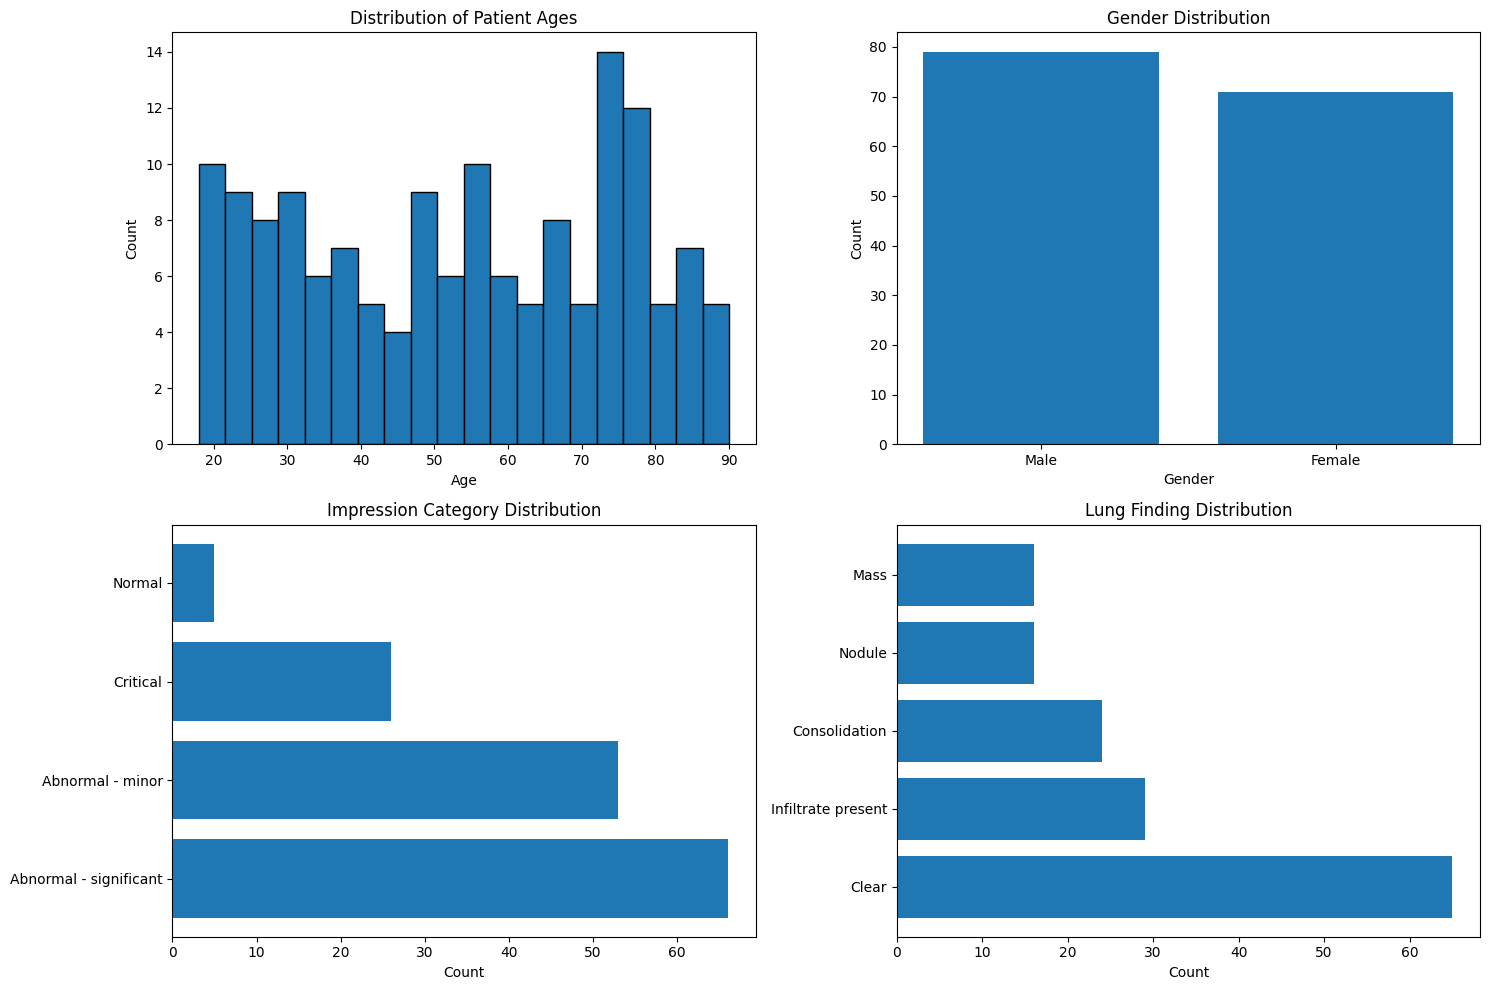

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(df_radiology["age"], bins=20, edgecolor="black")
axes[0, 0].set_title("Distribution of Patient Ages")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Count")

gender_counts = df_radiology["gender"].value_counts()
axes[0, 1].bar(gender_counts.index, gender_counts.values)
axes[0, 1].set_title("Gender Distribution")
axes[0, 1].set_xlabel("Gender")
axes[0, 1].set_ylabel("Count")

impression_counts = df_radiology["impression_category"].value_counts()
axes[1, 0].barh(impression_counts.index, impression_counts.values)
axes[1, 0].set_title("Impression Category Distribution")
axes[1, 0].set_xlabel("Count")

lung_counts = df_radiology["lung_finding"].value_counts()
axes[1, 1].barh(lung_counts.index, lung_counts.values)
axes[1, 1].set_title("Lung Finding Distribution")
axes[1, 1].set_xlabel("Count")

plt.tight_layout()
plt.show()

Step 6: Correlation Heatmap

This step encodes text categories as numbers so we can create a simple heatmap.

Important beginner note:

This is useful for practice, but label-encoded categorical correlations should not be treated as strong clinical evidence.

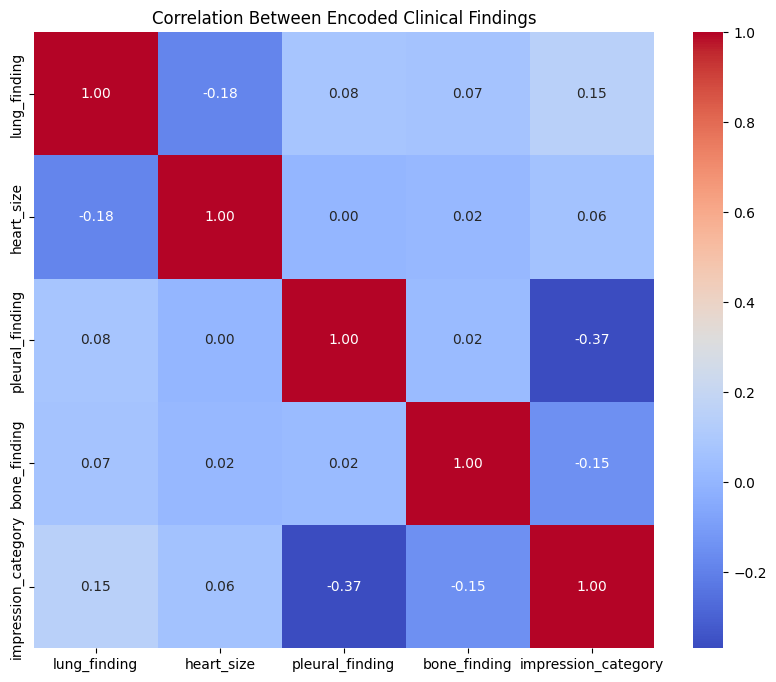

In [9]:
df_encoded = df_radiology.copy()

categorical_cols = [
    "lung_finding",
    "heart_size",
    "pleural_finding",
    "bone_finding",
    "impression_category"
]

encoder = LabelEncoder()

for col in categorical_cols:
    df_encoded[col + "_encoded"] = encoder.fit_transform(df_encoded[col])

encoded_cols = [col + "_encoded" for col in categorical_cols]

correlation_matrix = df_encoded[encoded_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    xticklabels=categorical_cols,
    yticklabels=categorical_cols
)
plt.title("Correlation Between Encoded Clinical Findings")
plt.show()

### Impact Analysis: Findings vs. Impression
This table shows exactly how our logic mapped specific lung findings to the final impression categories.

In [10]:
import pandas as pd

# Create a cross-tabulation of lung findings vs impression categories
impact_table = pd.crosstab(df_radiology['lung_finding'], df_radiology['impression_category'])

# Display the table
display(impact_table)

impression_category,Abnormal - minor,Abnormal - significant,Critical,Normal
lung_finding,,,,
Clear,39,17,4,5
Consolidation,0,21,3,0
Infiltrate present,0,27,2,0
Mass,0,0,16,0
Nodule,14,1,1,0


Step 7: Generate Clinical History Section

A radiology report usually has a Clinical History section.

This function uses:

age
gender
indication

Example:

65-year-old male with cough and fever.

In [14]:
def generate_clinical_history(row):
    age = row["age"]
    gender = row["gender"].lower()
    indication = row["indication"].lower()

    history = f"{age}-year-old {gender} with {indication}."

    return history

Step 8: Generate Technique Section

The Technique section describes how the imaging study was done.

Example:

Chest X-ray PA and Lateral performed on 2025-01-20.

In [15]:
def generate_technique(row):
    modality = row["modality"]
    exam_date = row["exam_date"]

    technique = f"{modality} performed on {exam_date}."

    if np.random.random() > 0.5:
        technique += " No prior studies available for comparison."
    else:
        technique += " Comparison made with prior study when available."

    return technique

Step 9: Generate Findings Section

The Findings section describes what is seen on the image.

The function uses rule-based text generation.

Example:

If lung finding is Clear, write a normal lung sentence.

If lung finding is Consolidation, write a pneumonia-style finding sentence.

In [16]:
def generate_findings(row):
    findings = []

    lung_finding = row["lung_finding"]

    if lung_finding == "Clear":
        findings.append(
            "The lungs are clear bilaterally without focal consolidation, effusion, or pneumothorax."
        )

    elif lung_finding == "Infiltrate present":
        location = np.random.choice([
            "right lower lobe",
            "left lower lobe",
            "right upper lobe",
            "left upper lobe"
        ])
        findings.append(
            f"Patchy infiltrate noted in the {location}, suggestive of infection or inflammation."
        )

    elif lung_finding == "Consolidation":
        location = np.random.choice([
            "right lower lobe",
            "left lower lobe",
            "bilateral lower lobes"
        ])
        findings.append(
            f"Consolidation present in the {location}, consistent with pneumonia."
        )

    elif lung_finding == "Nodule":
        size = np.random.choice(["5 mm", "8 mm", "1.2 cm"])
        location = np.random.choice([
            "right upper lobe",
            "left upper lobe",
            "right middle lobe"
        ])
        findings.append(
            f"A {size} pulmonary nodule is seen in the {location}."
        )

    elif lung_finding == "Mass":
        size = np.random.choice(["2.8 cm", "3.2 cm", "4.1 cm"])
        location = np.random.choice([
            "right upper lobe",
            "left upper lobe",
            "right lower lobe"
        ])
        findings.append(
            f"A {size} mass is present in the {location}. Further evaluation is recommended."
        )

    heart_size = row["heart_size"]

    if heart_size == "Normal":
        findings.append("The cardiac silhouette is normal in size.")
    elif heart_size == "Borderline enlarged":
        findings.append("The cardiac silhouette is borderline enlarged.")
    elif heart_size == "Enlarged":
        findings.append("Cardiomegaly is present.")

    pleural_finding = row["pleural_finding"]

    if pleural_finding == "No effusion":
        findings.append("No pleural effusion or pneumothorax is identified.")
    elif pleural_finding == "Small effusion":
        side = np.random.choice(["right", "left"])
        findings.append(f"Small {side} pleural effusion is present.")
    elif pleural_finding == "Moderate effusion":
        side = np.random.choice(["right", "left"])
        findings.append(f"Moderate {side} pleural effusion is present.")
    elif pleural_finding == "Large effusion":
        side = np.random.choice(["right", "left"])
        findings.append(f"Large {side} pleural effusion is present with associated atelectatic change.")

    bone_finding = row["bone_finding"]

    if bone_finding == "No acute fracture":
        findings.append("No acute osseous abnormality is identified.")
    elif bone_finding == "Rib fracture":
        side = np.random.choice(["right", "left"])
        rib = np.random.choice(["5th", "6th", "7th", "8th"])
        findings.append(f"Acute fracture of the {side} {rib} rib is noted.")
    elif bone_finding == "Clavicle fracture":
        side = np.random.choice(["right", "left"])
        findings.append(f"Acute fracture of the {side} clavicle is present.")
    elif bone_finding == "Degenerative changes":
        findings.append("Mild degenerative changes of the thoracic spine are present.")

    additional_finding = row["additional_finding"]

    if additional_finding != "None":
        findings.append(f"Additional finding: {additional_finding.lower()}.")

    return " ".join(findings)

Step 10: Generate Impression Section

The Impression section gives the short conclusion.

Findings are detailed.

Impression is the summary.

Example:

Findings: Consolidation in right lower lobe.

Impression: Pneumonia. Recommend appropriate therapy and follow-up imaging.

In [17]:
def generate_impression(row):
    impressions = []
    number = 1

    lung_finding = row["lung_finding"]

    if lung_finding == "Clear":
        impressions.append(f"{number}. No acute cardiopulmonary abnormality.")
        number += 1

    elif lung_finding == "Infiltrate present":
        impressions.append(
            f"{number}. Pulmonary infiltrate, likely infectious or inflammatory. Clinical correlation recommended."
        )
        number += 1

    elif lung_finding == "Consolidation":
        impressions.append(
            f"{number}. Pneumonia. Recommend appropriate antibiotic therapy and follow-up imaging."
        )
        number += 1

    elif lung_finding == "Nodule":
        impressions.append(
            f"{number}. Pulmonary nodule. Recommend follow-up CT chest in 3 to 6 months depending on risk factors."
        )
        number += 1

    elif lung_finding == "Mass":
        impressions.append(
            f"{number}. Lung mass. Urgent CT chest and specialist consultation recommended."
        )
        number += 1

    pleural_finding = row["pleural_finding"]

    if pleural_finding == "Small effusion":
        impressions.append(f"{number}. Small pleural effusion.")
        number += 1

    elif pleural_finding == "Moderate effusion":
        impressions.append(f"{number}. Moderate pleural effusion. Clinical correlation recommended.")
        number += 1

    elif pleural_finding == "Large effusion":
        impressions.append(
            f"{number}. Large pleural effusion. Consider drainage evaluation if clinically indicated."
        )
        number += 1

    bone_finding = row["bone_finding"]

    if bone_finding in ["Rib fracture", "Clavicle fracture"]:
        impressions.append(f"{number}. Acute fracture identified.")
        number += 1

    heart_size = row["heart_size"]

    if heart_size == "Enlarged":
        impressions.append(f"{number}. Cardiomegaly.")
        number += 1

    if len(impressions) == 0:
        impressions.append("1. No acute abnormality.")

    return "\n".join(impressions)

Step 11: Generate Recommendations Section

This section adds possible next-step recommendations based on findings.

This is still rule-based and educational.

In [18]:
def generate_recommendations(row):
    recommendations = []

    lung_finding = row["lung_finding"]
    pleural_finding = row["pleural_finding"]
    bone_finding = row["bone_finding"]
    impression_category = row["impression_category"]

    if impression_category == "Normal":
        recommendations.append("Routine clinical follow-up as appropriate.")

    if lung_finding == "Consolidation":
        recommendations.append("Correlate clinically for pneumonia and consider follow-up imaging after treatment.")

    if lung_finding == "Infiltrate present":
        recommendations.append("Clinical correlation for infection or inflammation is recommended.")

    if lung_finding == "Nodule":
        recommendations.append("Consider follow-up chest CT depending on patient risk factors.")

    if lung_finding == "Mass":
        recommendations.append("Urgent CT chest and specialist consultation recommended.")

    if pleural_finding in ["Moderate effusion", "Large effusion"]:
        recommendations.append("Consider clinical evaluation for pleural effusion management.")

    if bone_finding in ["Rib fracture", "Clavicle fracture"]:
        recommendations.append("Correlate with trauma history and consider pain management or orthopedic review.")

    if len(recommendations) == 0:
        recommendations.append("No specific imaging follow-up recommendation generated by this prototype.")

    return "\n".join([f"- {item}" for item in recommendations])

Step 12: Generate a Complete Radiology Report

Now we combine all sections:

patient information
clinical history
technique
findings
impression
recommendations

In [19]:
def generate_complete_report(row):
    report = "=" * 80 + "\n"
    report += "RADIOLOGY REPORT\n"
    report += "=" * 80 + "\n\n"

    report += f"Patient ID: {row['patient_id']}\n"
    report += f"Age: {row['age']} years\n"
    report += f"Gender: {row['gender']}\n"
    report += f"Exam Date: {row['exam_date']}\n"
    report += f"Modality: {row['modality']}\n"

    report += "\n" + "-" * 80 + "\n\n"

    report += "CLINICAL HISTORY:\n"
    report += generate_clinical_history(row) + "\n\n"

    report += "TECHNIQUE:\n"
    report += generate_technique(row) + "\n\n"

    report += "FINDINGS:\n"
    report += generate_findings(row) + "\n\n"

    report += "IMPRESSION:\n"
    report += generate_impression(row) + "\n\n"

    report += "RECOMMENDATIONS:\n"
    report += generate_recommendations(row) + "\n\n"

    report += "-" * 80 + "\n"
    report += "Generated by educational template-based report generation system.\n"
    report += "Requires clinician/radiologist review before clinical use.\n"

    return report

Step 13: Generate Reports for All Exams

We apply the report generation function to every row.

In [20]:
df_radiology["generated_report"] = df_radiology.apply(generate_complete_report, axis=1)

print("Reports generated:", len(df_radiology))

Reports generated: 150


Step 14: View Example Reports

We will print one normal report, one abnormal report, and one critical report.

In [21]:
normal_reports = df_radiology[df_radiology["impression_category"] == "Normal"]

if len(normal_reports) > 0:
    print(normal_reports.iloc[0]["generated_report"])
else:
    print("No normal report found.")

RADIOLOGY REPORT

Patient ID: MRN100037
Age: 47 years
Gender: Male
Exam Date: 2025-12-29
Modality: CT Chest without contrast

--------------------------------------------------------------------------------

CLINICAL HISTORY:
47-year-old male with routine screening.

TECHNIQUE:
CT Chest without contrast performed on 2025-12-29. No prior studies available for comparison.

FINDINGS:
The lungs are clear bilaterally without focal consolidation, effusion, or pneumothorax. The cardiac silhouette is normal in size. No pleural effusion or pneumothorax is identified. Mild degenerative changes of the thoracic spine are present.

IMPRESSION:
1. No acute cardiopulmonary abnormality.

RECOMMENDATIONS:
- Routine clinical follow-up as appropriate.

--------------------------------------------------------------------------------
Generated by educational template-based report generation system.
Requires clinician/radiologist review before clinical use.



In [22]:
abnormal_reports = df_radiology[df_radiology["impression_category"] == "Abnormal - significant"]

if len(abnormal_reports) > 0:
    print(abnormal_reports.iloc[0]["generated_report"])
else:
    print("No abnormal significant report found.")

RADIOLOGY REPORT

Patient ID: MRN100000
Age: 69 years
Gender: Male
Exam Date: 2025-08-25
Modality: Chest X-ray PA and Lateral

--------------------------------------------------------------------------------

CLINICAL HISTORY:
69-year-old male with cough and fever.

TECHNIQUE:
Chest X-ray PA and Lateral performed on 2025-08-25. Comparison made with prior study when available.

FINDINGS:
Patchy infiltrate noted in the left upper lobe, suggestive of infection or inflammation. The cardiac silhouette is normal in size. No pleural effusion or pneumothorax is identified. No acute osseous abnormality is identified. Additional finding: calcified granuloma.

IMPRESSION:
1. Pulmonary infiltrate, likely infectious or inflammatory. Clinical correlation recommended.

RECOMMENDATIONS:
- Clinical correlation for infection or inflammation is recommended.

--------------------------------------------------------------------------------
Generated by educational template-based report generation system.
R

In [23]:
critical_reports = df_radiology[df_radiology["impression_category"] == "Critical"]

if len(critical_reports) > 0:
    print(critical_reports.iloc[0]["generated_report"])
else:
    print("No critical report found.")

RADIOLOGY REPORT

Patient ID: MRN100007
Age: 79 years
Gender: Female
Exam Date: 2025-10-22
Modality: Chest X-ray Portable

--------------------------------------------------------------------------------

CLINICAL HISTORY:
79-year-old female with post-operative evaluation.

TECHNIQUE:
Chest X-ray Portable performed on 2025-10-22. Comparison made with prior study when available.

FINDINGS:
Patchy infiltrate noted in the right lower lobe, suggestive of infection or inflammation. The cardiac silhouette is normal in size. Large left pleural effusion is present with associated atelectatic change. No acute osseous abnormality is identified. Additional finding: calcified granuloma.

IMPRESSION:
1. Pulmonary infiltrate, likely infectious or inflammatory. Clinical correlation recommended.
2. Large pleural effusion. Consider drainage evaluation if clinically indicated.

RECOMMENDATIONS:
- Clinical correlation for infection or inflammation is recommended.
- Consider clinical evaluation for pleura

Step 15: Analyze Report Length

We calculate:

character count
word count
average report length
minimum and maximum report length

In [24]:
df_radiology["report_length"] = df_radiology["generated_report"].apply(len)
df_radiology["report_word_count"] = df_radiology["generated_report"].apply(lambda text: len(text.split()))

print("Report Length Statistics")
print("=" * 40)
print("Average characters:", round(df_radiology["report_length"].mean(), 1))
print("Average words:", round(df_radiology["report_word_count"].mean(), 1))
print("Minimum words:", df_radiology["report_word_count"].min())
print("Maximum words:", df_radiology["report_word_count"].max())

Report Length Statistics
Average characters: 1214.0
Average words: 117.8
Minimum words: 98
Maximum words: 158


In [26]:
report_length_by_category = df_radiology.groupby("impression_category")["report_word_count"].agg(
    ["mean", "min", "max", "count"]
)

report_length_by_category

,mean,min,max,count
impression_category,,,,
Abnormal - minor,112.547170,102,126,53
Abnormal - significant,119.530303,108,151,66
Critical,127.038462,108,158,26
Normal,102.200000,98,104,5


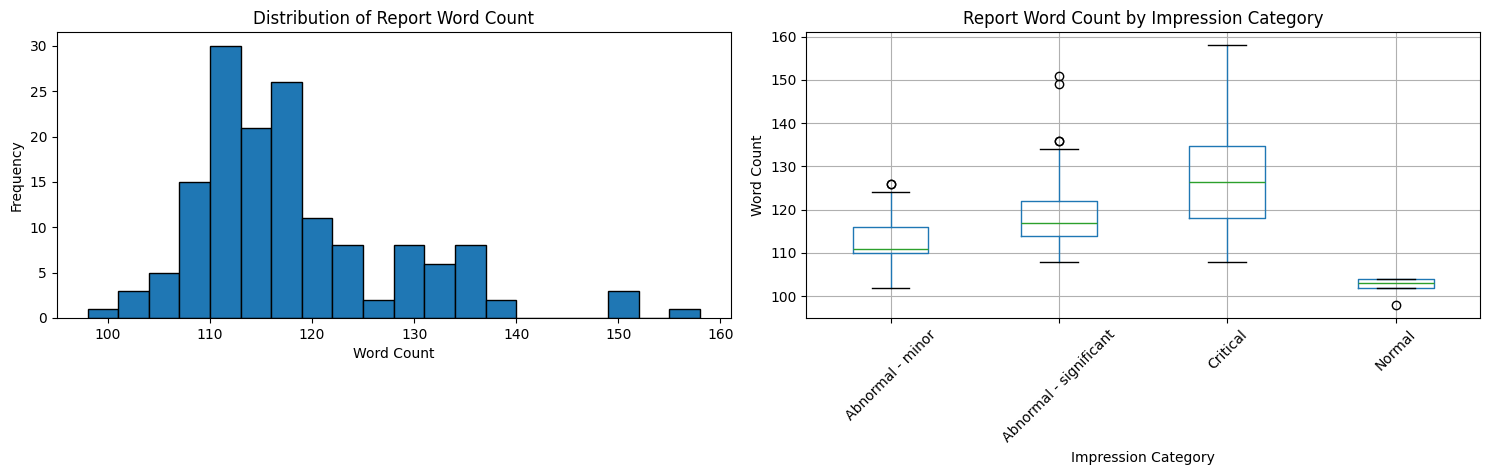

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df_radiology["report_word_count"], bins=20, edgecolor="black")
axes[0].set_title("Distribution of Report Word Count")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")

df_radiology.boxplot(
    column="report_word_count",
    by="impression_category",
    ax=axes[1],
    rot=45
)
axes[1].set_title("Report Word Count by Impression Category")
axes[1].set_xlabel("Impression Category")
axes[1].set_ylabel("Word Count")

plt.suptitle("")
plt.tight_layout()
plt.show()

Step 16: Report Quality Check

We check whether each report contains required sections:

Clinical History
Technique
Findings
Impression
Recommendations
Patient ID

In [28]:
def check_report_completeness(report_text):
    checks = {
        "has_patient_id": "Patient ID:" in report_text,
        "has_clinical_history": "CLINICAL HISTORY:" in report_text,
        "has_technique": "TECHNIQUE:" in report_text,
        "has_findings": "FINDINGS:" in report_text,
        "has_impression": "IMPRESSION:" in report_text,
        "has_recommendations": "RECOMMENDATIONS:" in report_text
    }

    checks["is_complete"] = all(checks.values())

    return checks

In [30]:
completeness_results = df_radiology["generated_report"].apply(check_report_completeness)
completeness_df = pd.DataFrame(completeness_results.tolist())

completeness_summary = completeness_df.sum().reset_index()
completeness_summary.columns = ["quality_check", "count"]

completeness_summary

,quality_check,count
0,has_patient_id,150
1,has_clinical_history,150
2,has_technique,150
3,has_findings,150
4,has_impression,150
5,has_recommendations,150
6,is_complete,150


Step 17: Report Content Analysis

Now we check whether reports mention:

recommendation
urgent
normal
abnormal
numbered impression

This helps us understand report content quality.

In [31]:
def analyze_report_content(report_text):
    text = report_text.lower()

    metrics = {
        "mentions_recommendation": "recommend" in text,
        "mentions_urgent": "urgent" in text,
        "mentions_normal": "normal" in text,
        "mentions_abnormal": any(
            word in text for word in ["abnormal", "consolidation", "effusion", "mass", "fracture"]
        ),
        "numbered_impression": any(f"{i}." in report_text for i in range(1, 10))
    }

    return metrics

In [32]:
content_results = df_radiology["generated_report"].apply(analyze_report_content)
content_df = pd.DataFrame(content_results.tolist())

content_summary = content_df.sum().reset_index()
content_summary.columns = ["content_metric", "count"]

content_summary

,content_metric,count
0,mentions_recommendation,150
1,mentions_urgent,16
2,mentions_normal,142
3,mentions_abnormal,150
4,numbered_impression,150


Step 18: Generate Report Statistics Summary

This function creates a readable summary of the whole report dataset.

In [33]:
def generate_report_statistics(df):
    total_reports = len(df)
    normal_count = len(df[df["impression_category"] == "Normal"])
    abnormal_count = total_reports - normal_count

    most_common_lung = df["lung_finding"].value_counts().idxmax()
    most_common_pleural = df["pleural_finding"].value_counts().idxmax()
    most_common_bone = df["bone_finding"].value_counts().idxmax()

    average_words = df["report_word_count"].mean()

    category_summary = df["impression_category"].value_counts()

    summary = ""
    summary += "RADIOLOGY REPORT DATASET STATISTICS\n"
    summary += "=" * 60 + "\n"
    summary += f"Total reports generated: {total_reports}\n"
    summary += f"Normal reports: {normal_count} ({normal_count / total_reports * 100:.1f}%)\n"
    summary += f"Abnormal or critical reports: {abnormal_count} ({abnormal_count / total_reports * 100:.1f}%)\n"
    summary += f"Average report word count: {average_words:.1f}\n\n"

    summary += "Most common findings:\n"
    summary += f"- Lung finding: {most_common_lung}\n"
    summary += f"- Pleural finding: {most_common_pleural}\n"
    summary += f"- Bone finding: {most_common_bone}\n\n"

    summary += "Impression category counts:\n"
    for category, count in category_summary.items():
        summary += f"- {category}: {count}\n"

    return summary


print(generate_report_statistics(df_radiology))

RADIOLOGY REPORT DATASET STATISTICS
Total reports generated: 150
Normal reports: 5 (3.3%)
Abnormal or critical reports: 145 (96.7%)
Average report word count: 117.8

Most common findings:
- Lung finding: Clear
- Pleural finding: No effusion
- Bone finding: No acute fracture

Impression category counts:
- Abnormal - significant: 66
- Abnormal - minor: 53
- Critical: 26
- Normal: 5



Step 19: Compare Two Reports

This function compares two imaging records.

It can show if findings improved, worsened, or changed.

In [36]:
def compare_reports(prior_row, current_row):
    comparison = ""
    comparison += "REPORT COMPARISON SUMMARY\n"
    comparison += "=" * 60 + "\n"

    comparison += f"Prior Exam Date: {prior_row['exam_date']}\n"
    comparison += f"Current Exam Date: {current_row['exam_date']}\n\n"

    fields_to_compare = [
        "lung_finding",
        "heart_size",
        "pleural_finding",
        "bone_finding",
        "additional_finding",
        "impression_category"
    ]

    for field in fields_to_compare:
        prior_value = prior_row[field]
        current_value = current_row[field]

        if prior_value == current_value:
            status = "Unchanged"
        else:
            status = "Changed"

        comparison += f"{field}:\n"
        comparison += f"  Prior: {prior_value}\n"
        comparison += f"  Current: {current_value}\n"
        comparison += f"  Status: {status}\n\n"

    return comparison

In [37]:
prior_row = df_radiology.iloc[0]
current_row = df_radiology.iloc[1]

print(compare_reports(prior_row, current_row))

REPORT COMPARISON SUMMARY
Prior Exam Date: 2025-08-25
Current Exam Date: 2025-12-24

lung_finding:
  Prior: Infiltrate present
  Current: Consolidation
  Status: Changed

heart_size:
  Prior: Normal
  Current: Enlarged
  Status: Changed

pleural_finding:
  Prior: No effusion
  Current: No effusion
  Status: Unchanged

bone_finding:
  Prior: No acute fracture
  Current: Degenerative changes
  Status: Changed

additional_finding:
  Prior: Calcified granuloma
  Current: None
  Status: Changed

impression_category:
  Prior: Abnormal - significant
  Current: Abnormal - significant
  Status: Unchanged




Step 20: Save Summary Dataset

We save the structured report summary as a CSV file.

This can be used for dashboards or GitHub project outputs.

In [38]:
summary_columns = [
    "patient_id",
    "age",
    "gender",
    "exam_date",
    "indication",
    "modality",
    "lung_finding",
    "heart_size",
    "pleural_finding",
    "bone_finding",
    "additional_finding",
    "impression_category",
    "report_word_count",
    "report_length"
]

df_summary = df_radiology[summary_columns]

df_summary.to_csv("radiology_reports_summary.csv", index=False)

print("Saved file: radiology_reports_summary.csv")

Saved file: radiology_reports_summary.csv


Step 21: Save Individual Reports

This saves the first 10 generated reports as .txt files.

In [40]:
reports_dir = "generated_reports"

os.makedirs(reports_dir, exist_ok=True)

num_reports_to_save = min(10, len(df_radiology))

for_saved_files = []

for i in range(num_reports_to_save):
    patient_id = df_radiology.iloc[i]["patient_id"]
    report_text = df_radiology.iloc[i]["generated_report"]

    file_path = f"{reports_dir}/report_{patient_id}.txt"

    with open(file_path, "w") as file:
        file.write(report_text)

    for_saved_files.append(file_path)

print(f"Saved {num_reports_to_save} reports to folder: {reports_dir}")
for_saved_files

Saved 10 reports to folder: generated_reports


['generated_reports/report_MRN100000.txt',
 'generated_reports/report_MRN100001.txt',
 'generated_reports/report_MRN100002.txt',
 'generated_reports/report_MRN100003.txt',
 'generated_reports/report_MRN100004.txt',
 'generated_reports/report_MRN100005.txt',
 'generated_reports/report_MRN100006.txt',
 'generated_reports/report_MRN100007.txt',
 'generated_reports/report_MRN100008.txt',
 'generated_reports/report_MRN100009.txt']

Step 22: Create Dashboard Summary Tables

These tables can help you create a dashboard.

In [41]:
impression_report = df_radiology["impression_category"].value_counts().reset_index()
impression_report.columns = ["impression_category", "count"]

lung_report = df_radiology["lung_finding"].value_counts().reset_index()
lung_report.columns = ["lung_finding", "count"]

modality_report = df_radiology["modality"].value_counts().reset_index()
modality_report.columns = ["modality", "count"]

impression_report

,impression_category,count
0,Abnormal - significant,66
1,Abnormal - minor,53
2,Critical,26
3,Normal,5


In [42]:
lung_report

,lung_finding,count
0,Clear,65
1,Infiltrate present,29
2,Consolidation,24
3,Nodule,16
4,Mass,16


In [43]:
modality_report

,modality,count
0,Chest X-ray PA and Lateral,54
1,Chest X-ray Portable,52
2,CT Chest without contrast,44


In [44]:
impression_report.to_csv("dashboard_impression_report.csv", index=False)
lung_report.to_csv("dashboard_lung_finding_report.csv", index=False)
modality_report.to_csv("dashboard_modality_report.csv", index=False)

print("Saved dashboard summary CSV files.")

Saved dashboard summary CSV files.
